# Setup


In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [2]:
def load_data(query):
    conn = psycopg2.connect(
        host="localhost",
        database="ecommerce_db",
        user="postgres",
        password="K210504",
        port=5432
    )
    df = pd.read_sql(query, conn)
    conn.close()
    return df


# Tren Penjualan Bulanan

C:\Users\khali\AppData\Local\Temp\ipykernel_39152\2275411944.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


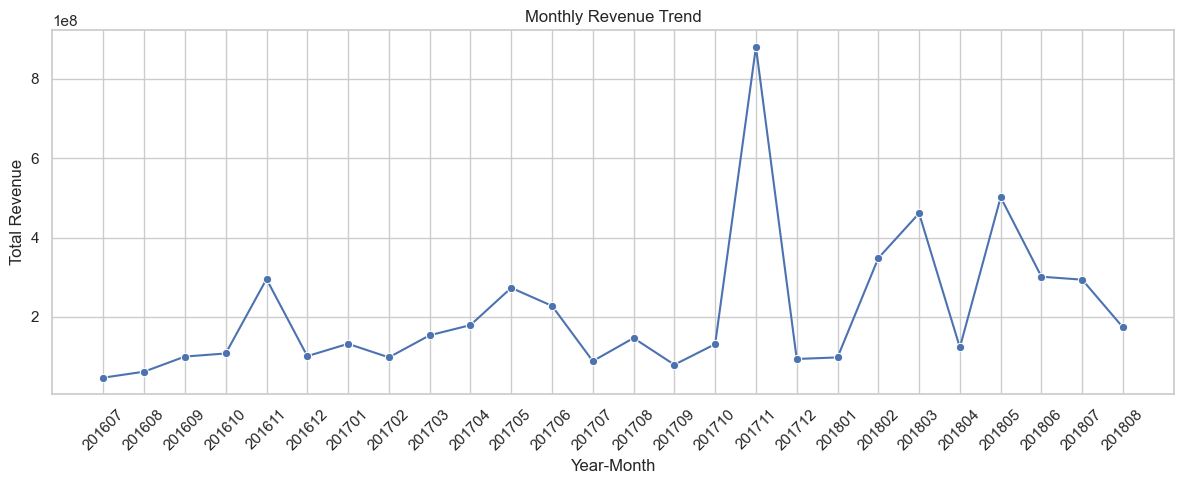

In [3]:
query = """
SELECT year_month_key, total_revenue
FROM mart.agg_monthly_sales
ORDER BY year_month_key;
"""

df_monthly = load_data(query)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=df_monthly,
    x="year_month_key",
    y="total_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# Holiday vs Non Holiday

C:\Users\khali\AppData\Local\Temp\ipykernel_39152\2275411944.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\khali\AppData\Local\Temp\ipykernel_39152\459819375.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


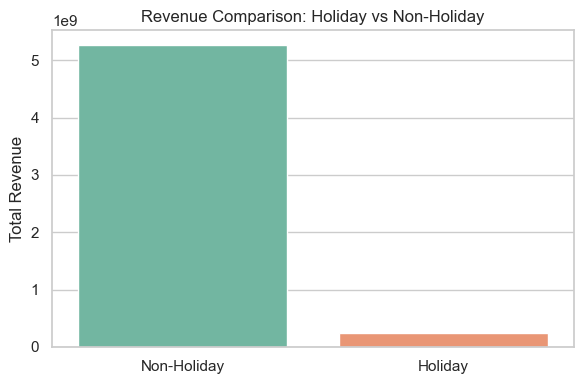

In [4]:
query = """
SELECT
    CASE WHEN is_holiday = 1 THEN 'Holiday' ELSE 'Non-Holiday' END AS day_type,
    total_revenue
FROM mart.agg_holiday_vs_nonholiday;
"""

df_holiday = load_data(query)

plt.figure(figsize=(6,4))
sns.barplot(
    data=df_holiday,
    x="day_type",
    y="total_revenue",
    palette="Set2"
)

plt.title("Revenue Comparison: Holiday vs Non-Holiday")
plt.xlabel("")
plt.ylabel("Total Revenue")
plt.tight_layout()

plt.show()


# Segmentasi Nilai Order

C:\Users\khali\AppData\Local\Temp\ipykernel_39152\2275411944.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\khali\AppData\Local\Temp\ipykernel_39152\3694815658.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


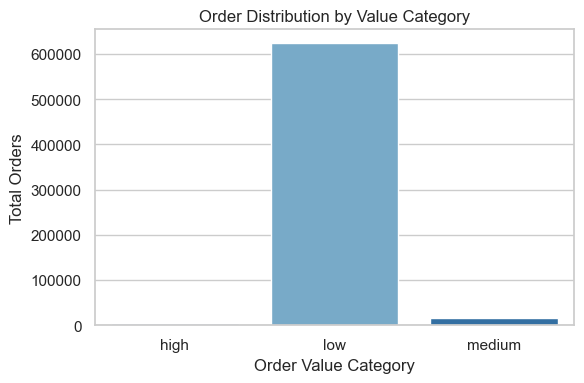

In [5]:
query = """
SELECT order_value_category, total_orders
FROM mart.agg_order_value_category;
"""

df_order_value = load_data(query)

plt.figure(figsize=(6,4))
sns.barplot(
    data=df_order_value,
    x="order_value_category",
    y="total_orders",
    palette="Blues"
)

plt.title("Order Distribution by Value Category")
plt.xlabel("Order Value Category")
plt.ylabel("Total Orders")
plt.tight_layout()

plt.show()


# Segmentasi Tenure Pelanggan

C:\Users\khali\AppData\Local\Temp\ipykernel_39152\2275411944.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\khali\AppData\Local\Temp\ipykernel_39152\4130551625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


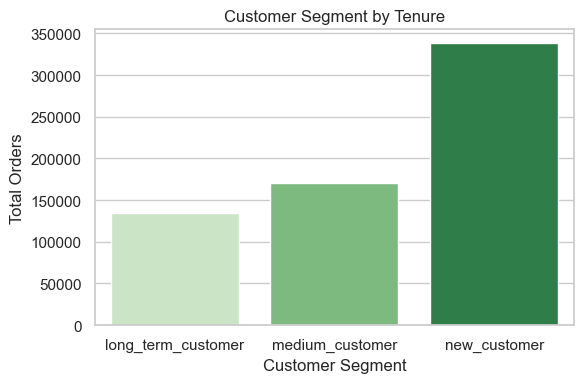

In [6]:
query = """
SELECT customer_segment, total_orders
FROM mart.agg_customer_tenure;
"""

df_tenure = load_data(query)

plt.figure(figsize=(6,4))
sns.barplot(
    data=df_tenure,
    x="customer_segment",
    y="total_orders",
    palette="Greens"
)

plt.title("Customer Segment by Tenure")
plt.xlabel("Customer Segment")
plt.ylabel("Total Orders")
plt.tight_layout()

plt.show()
